# Chapter 2 — Dispersion Suppressor

This notebook develops the dispersion suppressor in a SciBmad / Julia workflow.

## Goal

At the end of the arc, we want to connect into a straight section with **zero horizontal dispersion**.  
For a 90-degree FODO lattice, a natural first guess is to replace the bends in the last two cells by **half-strength bends**.  
That gives an approximate suppressor. Then we **optimize the strengths of the last two quadrupoles** so that

$$
\eta_x(\mathrm{end}) = 0,
\qquad
\eta_x'(\mathrm{end}) = 0.
$$

These two special quadrupoles are called **QFF1** and **QDF1**.

## Workflow in this notebook

1. Rebuild the optimized forward arc FODO cell from Chapter 1.
2. Extract the periodic one-cell optics and dispersion from its linear map.
3. Build the forward dispersion suppressor with half-strength bends.
4. Define a merit function from the end-of-line values of $\eta_x$ and $\eta_x'$.
5. Optimize the strengths of `QFF1` and `QDF1`.
6. Verify that the suppressor ends with zero dispersion.


In [5]:
# Run this cell once after switching to a new Julia kernel.
import Pkg
Pkg.add("Plots")

   Resolving package versions...
   Installed GR_jll ──────────────────── v0.73.26+0
   Installed Xorg_xkeyboard_config_jll ─ v2.47.0+1
   Installed MbedTLS_jll ─────────────── v2.28.1010+0
   Installed GR ──────────────────────── v0.73.26
   Installed BitFlags ────────────────── v0.1.10
  Installing 3 artifacts
   Installed artifact MbedTLS                 6.7 MiB
   Installed artifact Xorg_xkeyboard_config   1.1 MiB
   Installed artifact GR                      21.5 MiB
    Updating `C:\Users\JoeyN\.julia\environments\v1.12\Project.toml`
  [91a5bcdd] + Plots v1.41.6
    Updating `C:\Users\JoeyN\.julia\environments\v1.12\Manifest.toml`
  [d1d4a3ce] + BitFlags v0.1.10
  [944b1d66] + CodecZlib v0.7.8
  [f0e56b4a] + ConcurrentUtilities v2.5.1
  [460bff9d] + ExceptionUnwrapping v0.1.11
  [c87230d0] + FFMPEG v0.4.5
  [28b8d3ca] + GR v0.73.26
  [42e2da0e] + Grisu v1.0.2
⌅ [cd3eb016] + HTTP v1.11.0
  [1019f520] + JLFzf v0.1.11
  [23fbe1c1] + Latexify v0.16.10
  [e6f89c97] + LoggingExtras v1.

In [6]:
using SciBmad
using LinearAlgebra
using Printf
using Plots
using DifferentiationInterface
import DifferentiationInterface as DI
using GTPSA

species_ref = Species("electron")
E_ref = 18e9


1.8e10

## 1. Low-level helper functions

We will keep the optics extraction very explicit.

The idea is:

- use `track!` to propagate one particle through a `Beamline`,
- use `DifferentiationInterface` with `AutoGTPSA()` to compute the **Jacobian** of the end coordinates with respect to the initial coordinates,
- interpret that Jacobian as the **linear transfer map**.

For an open line, the horizontal dispersion at the end is obtained from the map by

$$
D_{\mathrm{end}} = A D_0 + b,
$$

where $A$ is the $2\times 2$ transverse block of the map, $D_0 = (\eta_x,\eta_x')^T$ is the entrance dispersion vector, and $b$ is the column multiplying the momentum offset coordinate.

For the periodic arc cell, the periodic dispersion satisfies

$$
D_0 = A D_0 + b
\quad\Longrightarrow\quad
(I-A)D_0 = b.
$$


In [7]:
function track_a_particle(v0, beamline)
    x = similar(v0)
    x .= v0
    bunch = Bunch(x; species=beamline.species_ref, p_over_q_ref=beamline.p_over_q_ref)
    track!(bunch, beamline)
    return copy(bunch.coords.v)
end

function linear_map(beamline; x0=zeros(6))
    prep = DI.prepare_jacobian(track_a_particle, AutoGTPSA(), x0, DI.Constant(beamline))
    return DI.jacobian(track_a_particle, prep, AutoGTPSA(), x0, DI.Constant(beamline))
end

function stable_phase_advance(M2)
    cμ = clamp(0.5 * tr(M2), -1.0, 1.0)
    return acos(cμ)
end

function periodic_twiss_from_map(M2)
    μ = stable_phase_advance(M2)
    sμ = sin(μ)
    β = M2[1, 2] / sμ
    α = (M2[1, 1] - M2[2, 2]) / (2sμ)
    return (β=β, α=α, μ=μ)
end

function propagate_twiss(A, tw0)
    β0 = tw0.β
    α0 = tw0.α
    γ0 = (1 + α0^2) / β0

    β = A[1,1]^2 * β0 - 2A[1,1]*A[1,2]*α0 + A[1,2]^2 * γ0
    α = -A[1,1]*A[2,1]*β0 + (A[1,1]*A[2,2] + A[1,2]*A[2,1])*α0 - A[1,2]*A[2,2]*γ0

    return (β=β, α=α)
end

function periodic_dispersion_from_map(M)
    A = M[1:2, 1:2]
    b = M[1:2, 6]
    D = (I - A) \ b
    return (η=D[1], ηp=D[2])
end

function transport_dispersion(M, D0)
    D = M[1:2, 1:2] * [D0.η, D0.ηp] + M[1:2, 6]
    return (η=D[1], ηp=D[2])
end

function gauss_newton(f, x0; step=1e-6, tol=1e-13, maxiter=20, damping=1.0, verbose=true)
    x = copy(x0)
    history = NamedTuple[]

    for it in 1:maxiter
        r = f(x)
        merit = 0.5 * dot(r, r)
        push!(history, (iter=it, x=copy(x), residual=copy(r), merit=merit))

        if verbose
            @printf(
                "iter %2d  merit = %.6e   x = [% .8f, % .8f]   residual = [% .3e, % .3e]\n",
                it, merit, x[1], x[2], r[1], r[2]
            )
        end

        if norm(r) < tol
            return x, history
        end

        J = zeros(2, 2)
        for j in 1:2
            xp = copy(x); xp[j] += step
            xm = copy(x); xm[j] -= step
            J[:, j] = (f(xp) - f(xm)) / (2 * step)
        end

        Δx = (J' * J) \ (J' * r)
        x -= damping * Δx

        if norm(Δx) < tol
            return x, history
        end
    end

    return x, history
end


gauss_newton (generic function with 1 method)

## 2. Rebuild the forward arc FODO cell from Chapter 1

This chapter starts from the **optimized forward arc cell**.  
To keep the notebook self-contained, we will recover that Chapter 1 result here by solving for the quadrupole strengths that give a **90-degree phase advance in both transverse planes**.

We use the following geometry:

- $QF$: focusing quadrupole, $L=0.5$
- $QD$: defocusing quadrupole, $L=0.5$
- $D1$: drift, $L=0.609$
- $D2$: drift, $L=1.241$
- $B$: bend, $L=6.86$, $\theta=\pi/132$

The forward arc cell is

$$
(QF,\ D1,\ B,\ D2,\ QD,\ D1,\ B,\ D2).
$$


In [8]:
function make_forward_arc_fodo(kqf, kqd)
    elements = [
        Quadrupole(L=0.5, Kn1=kqf),
        Drift(L=0.609),
        SBend(L=6.86, angle=π/132),
        Drift(L=1.241),
        Quadrupole(L=0.5, Kn1=kqd),
        Drift(L=0.609),
        SBend(L=6.86, angle=π/132),
        Drift(L=1.241),
    ]

    lengths = [0.5, 0.609, 6.86, 1.241, 0.5, 0.609, 6.86, 1.241]
    names = ["QF", "D1", "B1", "D2", "QD", "D1", "B2", "D2"]

    beamline = Beamline(elements; species_ref=Species("electron"), E_ref=18e9)
    return (; elements, lengths, names, beamline)
end

function fodo_phase_residuals(k)
    lat = Base.invokelatest(make_forward_arc_fodo, k[1], k[2])
    M = linear_map(lat.beamline)

    μx = stable_phase_advance(M[1:2, 1:2])
    μy = stable_phase_advance(M[3:4, 3:4])

    return [μx - π/2, μy - π/2]
end

k_arc0 = [0.4, -0.4]
k_arc, arc_history = Base.invokelatest() do
    gauss_newton(fodo_phase_residuals, k_arc0; step=1e-6, tol=1e-13, maxiter=20)
end
kQF_arc, kQD_arc = k_arc

@printf("Optimized arc strengths:\n")
@printf("  QF.Kn1 = %.12f\n", kQF_arc)
@printf("  QD.Kn1 = %.12f\n", kQD_arc)


iter  1  merit = 4.741102e-01   x = [ 0.40000000, -0.40000000]   residual = [ 6.892e-01,  6.879e-01]
iter  2  merit = 2.175649e-02   x = [ 0.33490916, -0.33497596]   residual = [ 1.478e-01,  1.472e-01]
iter  3  merit = 3.259573e-05   x = [ 0.31355755, -0.31369002]   residual = [ 5.714e-03,  5.704e-03]
iter  4  merit = 6.673215e-11   x = [ 0.31266597, -0.31279976]   residual = [ 8.168e-06,  8.170e-06]
iter  5  merit = 2.786296e-22   x = [ 0.31266470, -0.31279848]   residual = [ 1.669e-11,  1.669e-11]
iter  6  merit = 2.465190e-32   x = [ 0.31266470, -0.31279848]   residual = [ 0.000e+00, -2.220e-16]
Optimized arc strengths:
  QF.Kn1 = 0.312664696121
  QD.Kn1 = -0.312798481524


In [9]:
arc = make_forward_arc_fodo(kQF_arc, kQD_arc)
M_arc = linear_map(arc.beamline)

twiss_x0 = periodic_twiss_from_map(M_arc[1:2, 1:2])
twiss_y0 = periodic_twiss_from_map(M_arc[3:4, 3:4])
disp0 = periodic_dispersion_from_map(M_arc)

@printf("Periodic one-cell optics of the arc:\n")
@printf("  beta_x(start)  = %.8f m\n", twiss_x0.β)
@printf("  alpha_x(start) = %.8f\n", twiss_x0.α)
@printf("  mu_x           = %.8f rad\n", twiss_x0.μ)
@printf("  beta_y(start)  = %.8f m\n", twiss_y0.β)
@printf("  alpha_y(start) = %.8f\n", twiss_y0.α)
@printf("  mu_y           = %.8f rad\n", twiss_y0.μ)
@printf("  eta_x(start)   = %.8e m\n", disp0.η)
@printf("  eta_x'(start)  = %.8e\n", disp0.ηp)


Periodic one-cell optics of the arc:
  beta_x(start)  = 30.62353345 m
  alpha_x(start) = -2.40147164
  mu_x           = 1.57079633 rad
  beta_y(start)  = 5.54893519 m
  alpha_y(start) = 0.47667405
  mu_y           = 1.57079633 rad
  eta_x(start)   = 5.86725314e-01 m
  eta_x'(start)  = 4.53320893e-02


## 3. Build the forward dispersion suppressor

Now we switch from a **periodic cell problem** to an **open transfer line** problem.

The suppressor layout is

$$
(QF,\ D1,\ BH,\ D2,\ QD,\ D1,\ BH,\ D2,\ QFF1,\ D1,\ BH,\ D2,\ QDF1,\ D1,\ BH,\ D2),
$$

where the bend `BH` has **half** the arc bending angle.  
The first two quadrupoles stay fixed at the optimized arc strengths.  
The last two quadrupoles, `QFF1` and `QDF1`, are the variables we will optimize.

We begin with the initial guess

$$
QFF1 = 0.3, \qquad QDF1 = -0.3.
$$


In [10]:
function make_forward_suppressor(kqf_arc, kqd_arc, kqff1, kqdf1)
    half_angle = (π/132) / 2

    elements = [
        Quadrupole(L=0.5, Kn1=kqf_arc),
        Drift(L=0.609),
        SBend(L=6.86, angle=half_angle),
        Drift(L=1.241),

        Quadrupole(L=0.5, Kn1=kqd_arc),
        Drift(L=0.609),
        SBend(L=6.86, angle=half_angle),
        Drift(L=1.241),

        Quadrupole(L=0.5, Kn1=kqff1),
        Drift(L=0.609),
        SBend(L=6.86, angle=half_angle),
        Drift(L=1.241),

        Quadrupole(L=0.5, Kn1=kqdf1),
        Drift(L=0.609),
        SBend(L=6.86, angle=half_angle),
        Drift(L=1.241),
    ]

    lengths = [
        0.5, 0.609, 6.86, 1.241,
        0.5, 0.609, 6.86, 1.241,
        0.5, 0.609, 6.86, 1.241,
        0.5, 0.609, 6.86, 1.241,
    ]

    names = [
        "QF", "D1", "BH1", "D2",
        "QD", "D1", "BH2", "D2",
        "QFF1", "D1", "BH3", "D2",
        "QDF1", "D1", "BH4", "D2",
    ]

    beamline = Beamline(elements; species_ref=Species("electron"), E_ref=18e9)
    return (; elements, lengths, names, beamline)
end

function suppressor_residuals(k_special)
    lat = Base.invokelatest(make_forward_suppressor, kQF_arc, kQD_arc, k_special[1], k_special[2])
    M = linear_map(lat.beamline)
    Dend = transport_dispersion(M, disp0)
    return [Dend.η, Dend.ηp]
end

function suppressor_merit(k_special; wη=1.0, wηp=1.0)
    r = Base.invokelatest(suppressor_residuals, k_special)
    return wη * r[1]^2 + wηp * r[2]^2
end

k_special0 = [0.3, -0.3]
r0 = Base.invokelatest() do
    suppressor_residuals(k_special0)
end

@printf("Unoptimized suppressor end conditions:\n")
@printf("  eta_x(end)  = %.8e m\n", r0[1])
@printf("  eta_x'(end) = %.8e\n", r0[2])
@printf("  merit       = %.8e\n", Base.invokelatest(suppressor_merit, k_special0))


Unoptimized suppressor end conditions:
  eta_x(end)  = 5.19221445e-02 m
  eta_x'(end) = 3.93709416e-03
  merit       = 2.71140980e-03


## 4. Scan the line before optimization

Before optimizing anything, it is useful to inspect the suppressor as built from the half-strength bends alone.

We propagate:

- the **periodic arc Twiss parameters** from the start of the open line,
- the **periodic arc dispersion vector** from the start of the open line.

That lets us look at the optics element-by-element along the suppressor.


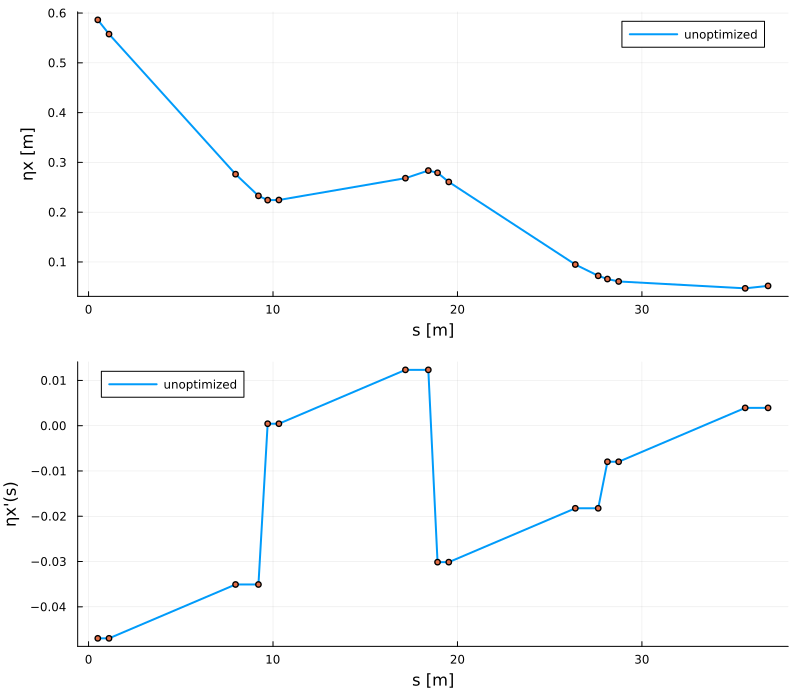

In [11]:
function optics_scan(elements, lengths, names, twx0, twy0, D0)
    n = length(elements)
    s = cumsum(lengths)

    ηx  = zeros(n)
    ηxp = zeros(n)
    βx  = zeros(n)
    βy  = zeros(n)

    for i in 1:n
        prefix = deepcopy_no_beamline.(elements[1:i])
        bl = Beamline(prefix; species_ref=Species("electron"), E_ref=18e9)
        M = linear_map(bl)

        D = transport_dispersion(M, D0)
        ηx[i]  = D.η
        ηxp[i] = D.ηp

        βx[i] = propagate_twiss(M[1:2, 1:2], twx0).β
        βy[i] = propagate_twiss(M[3:4, 3:4], twy0).β
    end

    return (; s, names, ηx, ηxp, βx, βy)
end

lat0 = make_forward_suppressor(kQF_arc, kQD_arc, k_special0[1], k_special0[2])
scan0 = Base.invokelatest(optics_scan, lat0.elements, lat0.lengths, lat0.names, twiss_x0, twiss_y0, disp0)

p1 = plot(scan0.s, scan0.ηx, lw=2, xlabel="s [m]", ylabel="ηx [m]", label="unoptimized")
scatter!(p1, scan0.s, scan0.ηx, label="", ms=3)

p2 = plot(scan0.s, scan0.ηxp, lw=2, xlabel="s [m]", ylabel="ηx'(s)", label="unoptimized")
scatter!(p2, scan0.s, scan0.ηxp, label="", ms=3)

plot(p1, p2, layout=(2, 1), size=(800, 700))


## 5. Merit function

Now we make the optimization problem explicit.

We want the suppressor to end with zero dispersion and zero dispersion derivative, so we define

$$
M(k_{QFF1}, k_{QDF1})
=
w_\eta\,\eta_x(\mathrm{end})^2
+
w_{\eta'}\,\eta_x'(\mathrm{end})^2.
$$

In this notebook we take both weights equal to 1.  
Because the problem is so small, a simple Gauss–Newton iteration is enough.


In [12]:
k_special, suppressor_history = gauss_newton(suppressor_residuals, k_special0; step=1e-6, tol=1e-14, maxiter=20)

kQFF1, kQDF1 = k_special
r_opt = suppressor_residuals(k_special)

@printf("Optimized suppressor strengths:\n")
@printf("  QFF1.Kn1 = %.12f\n", kQFF1)
@printf("  QDF1.Kn1 = %.12f\n", kQDF1)
@printf("\n")
@printf("Optimized end conditions:\n")
@printf("  eta_x(end)  = %.12e m\n", r_opt[1])
@printf("  eta_x'(end) = %.12e\n", r_opt[2])
@printf("  merit       = %.12e\n", suppressor_merit(k_special))


iter  1  merit = 1.355705e-03   x = [ 0.30000000, -0.30000000]   residual = [ 5.192e-02,  3.937e-03]
iter  2  merit = 3.626326e-07   x = [ 0.31293149, -0.31148959]   residual = [-8.463e-04, -9.549e-05]
iter  3  merit = 4.571394e-16   x = [ 0.31293916, -0.31523558]   residual = [-3.007e-08, -3.148e-09]
iter  4  merit = 9.938978e-30   x = [ 0.31293916, -0.31523568]   residual = [ 4.441e-15,  3.955e-16]
Optimized suppressor strengths:
  QFF1.Kn1 = 0.312939162568
  QDF1.Kn1 = -0.315235677243

Optimized end conditions:
  eta_x(end)  = 4.440892098501e-15 m
  eta_x'(end) = 3.955169525227e-16
  merit       = 1.987795629026e-29


## 6. Compare the unoptimized and optimized suppressor

The key check is very simple:

- before optimization, the half-bend construction gets us **close** to zero dispersion,
- after optimization, the last two quadrupole strengths make both $\eta_x$ and $\eta_x'$ vanish at the end of the line.

We also compare the beta functions to confirm that the optics were not dramatically distorted while suppressing the dispersion.


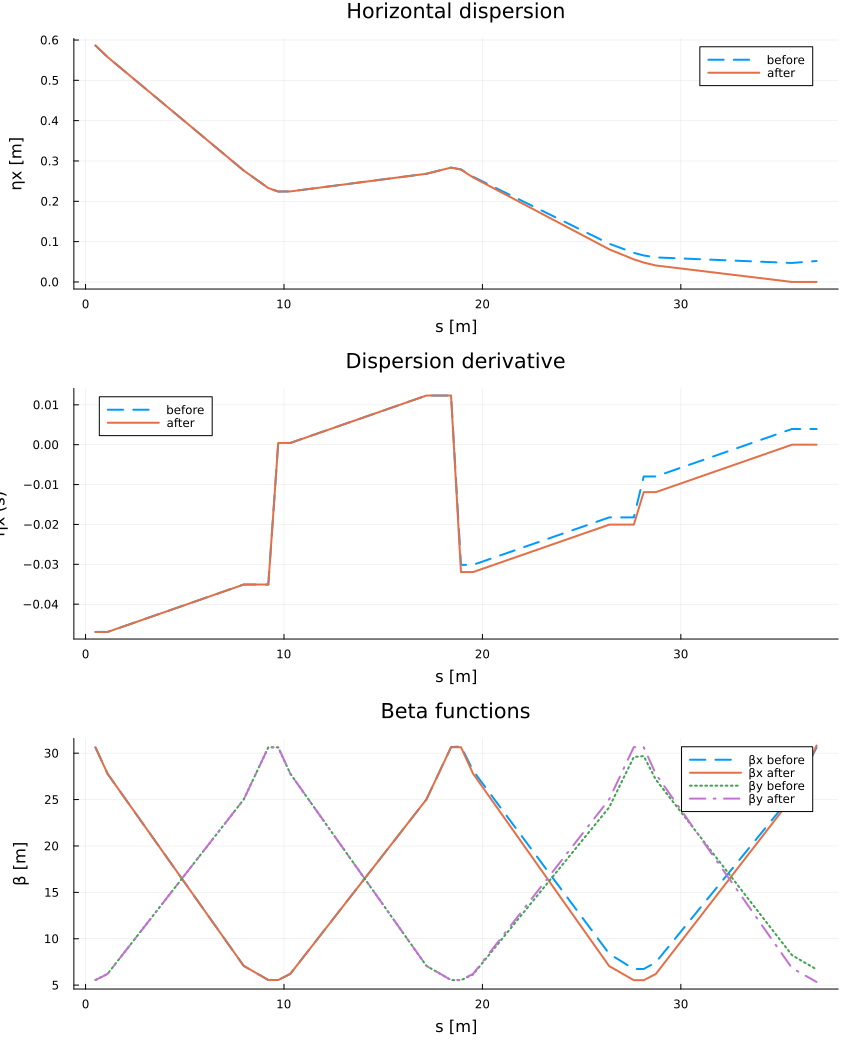

In [13]:
lat_opt = make_forward_suppressor(kQF_arc, kQD_arc, kQFF1, kQDF1)
scan_opt = optics_scan(lat_opt.elements, lat_opt.lengths, lat_opt.names, twiss_x0, twiss_y0, disp0)

pη = plot(scan0.s, scan0.ηx, lw=2, ls=:dash, label="before")
plot!(pη, scan_opt.s, scan_opt.ηx, lw=2, label="after")
xlabel!(pη, "s [m]")
ylabel!(pη, "ηx [m]")
title!(pη, "Horizontal dispersion")

pηp = plot(scan0.s, scan0.ηxp, lw=2, ls=:dash, label="before")
plot!(pηp, scan_opt.s, scan_opt.ηxp, lw=2, label="after")
xlabel!(pηp, "s [m]")
ylabel!(pηp, "ηx'(s)")
title!(pηp, "Dispersion derivative")

pβ = plot(scan0.s, scan0.βx, lw=2, ls=:dash, label="βx before")
plot!(pβ, scan_opt.s, scan_opt.βx, lw=2, label="βx after")
plot!(pβ, scan0.s, scan0.βy, lw=2, ls=:dot, label="βy before")
plot!(pβ, scan_opt.s, scan_opt.βy, lw=2, ls=:dashdot, label="βy after")
xlabel!(pβ, "s [m]")
ylabel!(pβ, "β [m]")
title!(pβ, "Beta functions")

plot(pη, pηp, pβ, layout=(3,1), size=(850, 1050))


## 7. Export the optimized strengths

After the optimization, it is convenient to write the optimized parameters to a small Julia file.  
Then the next notebook can simply `include(...)` that file and rebuild the line.


In [14]:
solution_text = """
# chapter2_dispsupF_solution.jl
# Auto-generated by Chapter 2 notebook.

kQF_arc = $(repr(kQF_arc))
kQD_arc = $(repr(kQD_arc))

kQFF1 = $(repr(kQFF1))
kQDF1 = $(repr(kQDF1))
"""

solution_path = joinpath("lattices", "chapter_2", "chapter2_dispsupF_solution.jl")
mkpath(dirname(solution_path))
write(solution_path, solution_text)

println("Wrote: ", solution_path)
println()
println(solution_text)


Wrote: lattices/chapter_2/chapter2_dispsupF_solution.jl

# chapter2_dispsupF_solution.jl
# Auto-generated by Chapter 2 notebook.

kQF_arc = 0.3126646961206133
kQD_arc = -0.3127984815244765

kQFF1 = 0.31293916256832
kQDF1 = -0.31523567724253193



## 8. Exercises

1. **Reverse dispersion suppressor.**  
   Construct the reverse dispersion suppressor by optimizing the last two quadrupole strengths so that $\eta_x = \eta_x' = 0$ exactly at the end for a 90-degree phase advance. Compare the optimized quadrupole values with those for the forward suppressor, and save the result as `dispsupR`.

2. **Forward and reversed cells.**  
   Check that your forward and reverse cells, both starting with focusing quadrupoles, have different periodic beta and alpha functions. Check also that, for the same 90-degree phase advance, they can still have exactly the same quadrupole strengths. Explain why this is consistent.

3. **Normal-mode dispersion.**  
   What is the difference between the horizontal and vertical dispersions $\eta_x, \eta_y$ and the normal-mode dispersions $\eta_a, \eta_b$ in the lattice being constructed? Verify the difference for one lattice element.

4. **Strength of bends.**  
   This is a harder exercise. For a dispersion suppressor between an arc FODO line and a straight FODO line, suppose the first suppressor cell has bend strengths reduced by a factor $\alpha$ and the second by a factor $1-\alpha$. Show, in the weak-bend approximation, that for 90-degree FODO cells one obtains $\alpha = 0.5$, and that for 60-degree FODO cells one obtains $\alpha = 0$.


